<a href="https://colab.research.google.com/github/nandiniverma08/ML_StudentModel_Project/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd

In [7]:
df = pd.read_csv("/content/placement.csv")

In [8]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [9]:
df.shape

(100, 4)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [12]:
df = df.iloc[:, 1:]

In [13]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [14]:
import matplotlib.pyplot as plt

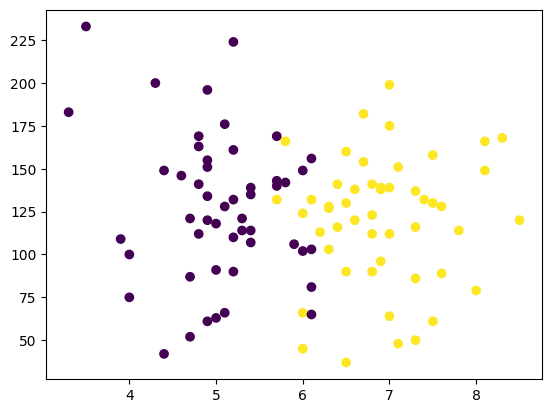

In [15]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])

In [42]:
x = df.iloc[:, 0:2]
y = df.iloc[:, -1]

In [17]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [18]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [43]:
y.shape

(100,)

In [47]:

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.1)

In [48]:
X_train

,cgpa,iq
55,7.8,114.0
91,7.5,158.0
50,3.5,233.0
70,6.3,127.0
48,6.6,138.0
...,...,...
26,7.0,199.0
39,4.6,146.0
69,8.5,120.0
74,6.7,154.0


In [49]:
y_train

,placement
55,1
91,1
50,0
70,1
48,1
...,...
26,1
39,0
69,1
74,1


In [50]:
X_test

,cgpa,iq
94,4.7,52.0
40,4.9,134.0
59,4.8,112.0
2,5.3,121.0
75,4.8,169.0
90,7.3,86.0
30,7.6,128.0
25,5.0,91.0
14,6.1,103.0
88,4.4,149.0


In [51]:
from sklearn.preprocessing import StandardScaler

In [52]:

scaler = StandardScaler()

In [53]:
X_train = scaler.fit_transform(X_train)

In [54]:
X_train

array([[ 1.54971546, -0.26212495],
       [ 1.28455502,  0.82708262],
       [-2.25091751,  2.68368644],
       [ 0.22391326,  0.05968637],
       [ 0.4890737 ,  0.33198827],
       [ 1.28455502,  0.13395053],
       [-0.57156806, -0.43540798],
       [-1.10188894,  0.40625242],
       [ 1.1961682 ,  0.18345996],
       [-0.92511531, -0.16310608],
       [-0.12963399, -0.4601627 ],
       [ 0.84262095,  1.24791282],
       [-0.8367285 ,  0.08444109],
       [-0.04124718,  0.60429016],
       [-0.04124718, -0.55918157],
       [ 1.8148759 ,  0.60429016],
       [ 0.75423414,  0.35674299],
       [-1.19027575, -0.08884193],
       [-0.30640762,  0.3814977 ],
       [-0.21802081,  0.43100714],
       [-1.89737026, -0.38589854],
       [ 0.13552645, -0.28687967],
       [ 0.66584733,  0.40625242],
       [ 1.8148759 ,  1.02512036],
       [ 0.75423414,  0.33198827],
       [ 0.75423414, -0.70770987],
       [ 0.04713963, -1.47510612],
       [ 0.31230007, -0.21261552],
       [-1.01350212,

In [55]:
X_test = scaler.transform(X_test)

In [56]:
X_test

array([[-1.19027575, -1.79691745],
       [-1.01350212,  0.2329694 ],
       [-1.10188894, -0.31163439],
       [-0.65995487, -0.08884193],
       [-1.10188894,  1.09938451],
       [ 1.10778139, -0.95525705],
       [ 1.37294183,  0.08444109],
       [-0.92511531, -0.83148346],
       [ 0.04713963, -0.53442685],
       [-1.45543619,  0.60429016]])

In [57]:

from sklearn.linear_model import LogisticRegression

In [58]:
clf = LogisticRegression()

In [59]:

# model training
clf.fit(X_train,y_train)

LogisticRegression()

In [62]:
y_pred = clf.predict(X_test)

In [61]:
y_test

,placement
94,0
40,0
59,0
2,0
75,0
90,1
30,1
25,0
14,0
88,0


In [63]:
from sklearn.metrics import accuracy_score

In [64]:
accuracy_score(y_test, y_pred)

0.9

In [65]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

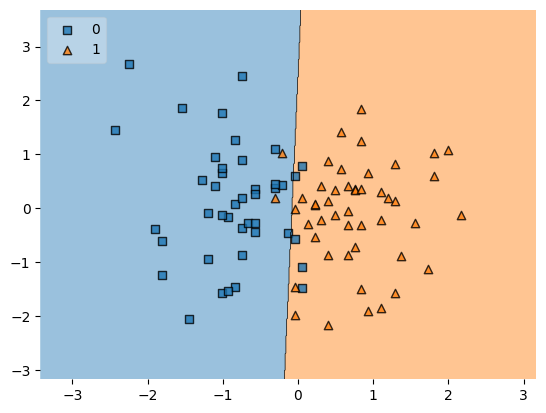

In [66]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [68]:
import pickle


In [69]:
pickle.dump(clf,open('model.pkl','wb'))